Troublshooting

In [11]:
#Troubleshooting Python Environment
import sys
print(sys.executable)

/Users/shaniabrace/Desktop/Spark/Projects/Python:netCDF/LPJ-EOSIM-Workspace/LPJ-EOSIM/.venv/bin/python


This notebook is to plot data from the LPJ-EOSIM output. 

In [12]:
#Import Packages
import xarray as xr
print("Successfully imported xarray")

import matplotlib.pyplot as plt
print("Successfully imported matplotlib")

import numpy as np
print("Successfully imported numpy")

import pandas as pd
print("Successfully imported pandas")

Successfully imported xarray
Successfully imported matplotlib
Successfully imported numpy
Successfully imported pandas


Before doing any type of analysis, I worked to understand each dataset. 

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 3900, longitude: 720, latitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 31kB 1700-01-01 1700-02-01 ... 2024-12-01
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    mgpp       (time, latitude, longitude) float32 4GB ...
{'units': 'kg C m-2 months -1', 'long_name': 'placeholder'}
('time', 'latitude', 'longitude')
(3900, 360, 720)
Coordinates:
  * time       (time) datetime64[ns] 31kB 1700-01-01 1700-02-01 ... 2024-12-01
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
-1.0184778e-10 0.44044048 0.061735418


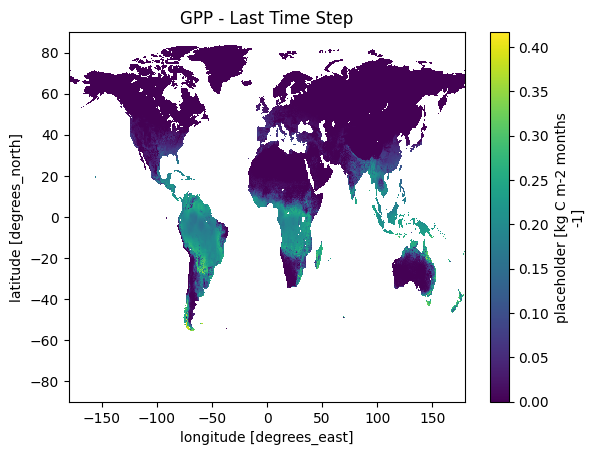

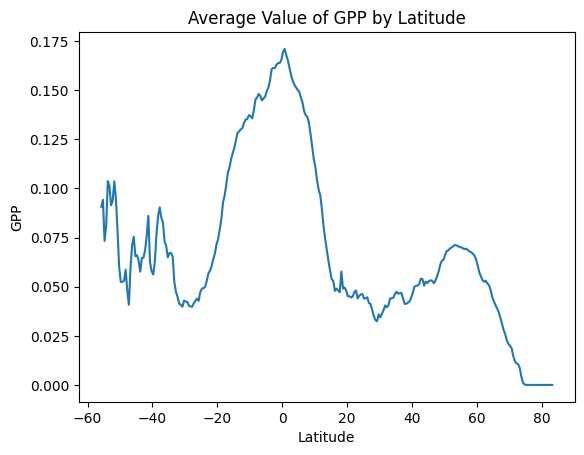

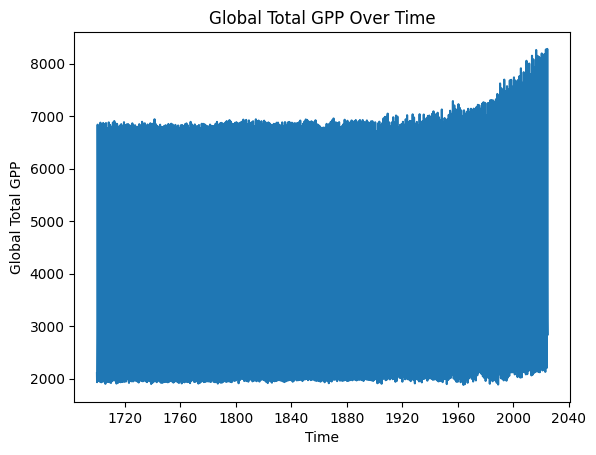

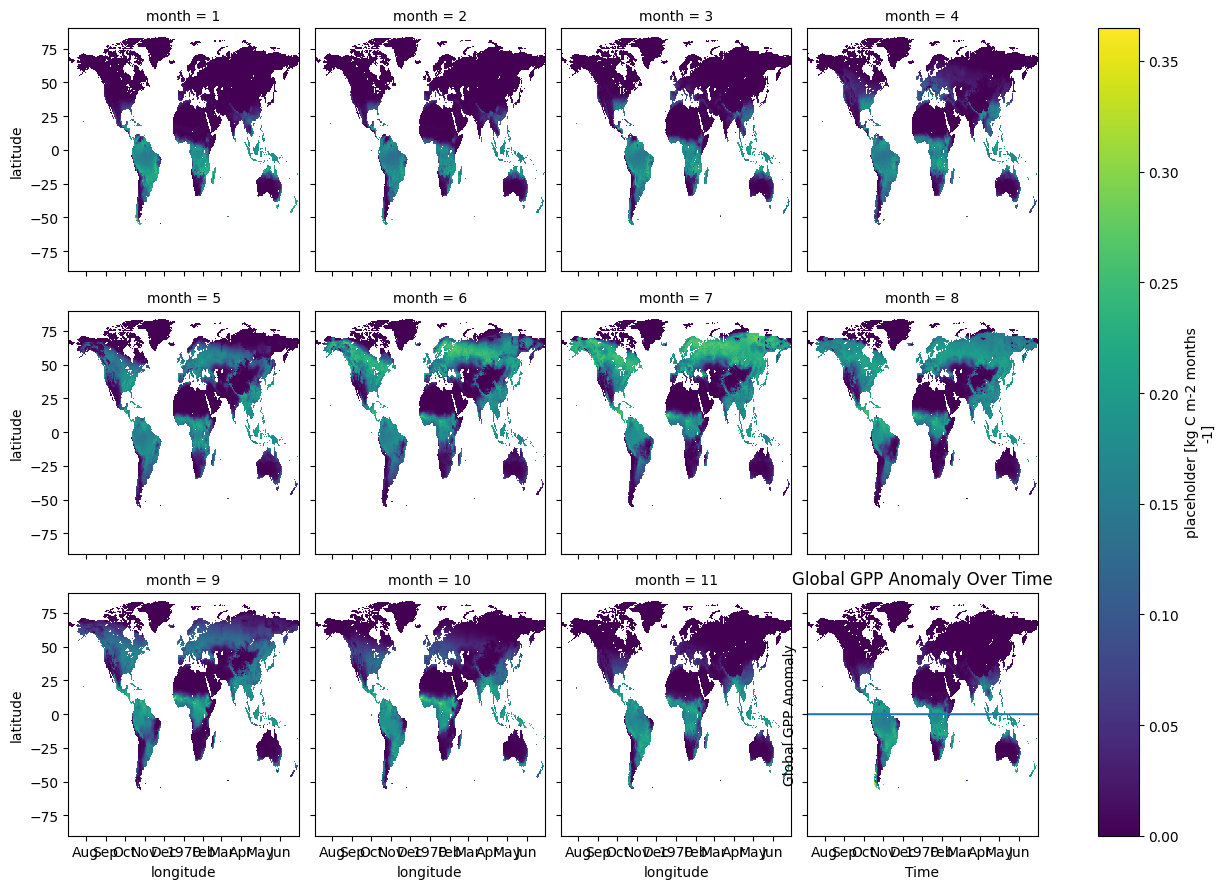

In [13]:
#Understanding the mgpp.nc dataset

#Variables, dimensions, and attributes of the dataset
gpp = xr.open_dataset('LPJ-EOSIM_S3_spitfire_N_mgpp.nc')
print(gpp)

mgpp = gpp['mgpp']

print(mgpp.attrs)
print(mgpp.dims)
print(mgpp.shape)
print(mgpp.coords)
print(mgpp.min().values, mgpp.max().values, mgpp.mean().values)



#Last Time Step of mgpp.nc. What does the world look like? 
mgpp.isel(time=-1).plot()

plt.title("GPP - Last Time Step")
plt.show()

#Average Value by Latitude. How do values change with latitude? 
lat_profile = mgpp.mean(dim=["longitude", "time"])

lat_profile.plot()
plt.title("Average Value of GPP by Latitude")
plt.xlabel("Latitude")
plt.ylabel("GPP")
plt.show()

#Global total GPP. How does the total GPP change over time?
global_total_gpp = mgpp.sum(dim=["latitude", "longitude"])

global_total_gpp.plot()
plt.title("Global Total GPP Over Time")
plt.xlabel("Time")
plt.ylabel("Global Total GPP")
plt.show()

#Weight of Grid Cells.
weights = np.cos(np.deg2rad(mgpp.latitude))
weights.name = "weights"
mgpp_weighted = mgpp.weighted(weights)

#Weighted lat profile
lat_profile_weighted = mgpp_weighted.mean(dim=["longitude", "time"])    

#Weighted global mean 
global_mean_weighted = mgpp_weighted.mean(dim=["latitude", "longitude", "time"])

#Seasonal Cycle. How does GPP change across seasons?
seasonal_cycle = mgpp.groupby("time.month").mean(dim=["time"])
seasonal_cycle.plot(col="month", col_wrap=4)

#GPP Anomaly
monthly_anomaly = mgpp.groupby("time.month") - mgpp.groupby("time.month").mean()
global_anomaly = monthly_anomaly.mean(dim=["latitude", "longitude"])

global_anomaly.plot()
plt.title("Global GPP Anomaly Over Time")
plt.xlabel("Time")
plt.ylabel("Global GPP Anomaly")
plt.show()

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 3900, longitude: 720, latitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 31kB 1700-01-01 1700-02-01 ... 2024-12-01
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    mnpp       (time, latitude, longitude) float32 4GB ...
{'units': 'kg C m-2 months -1', 'long_name': 'placeholder'}
('time', 'latitude', 'longitude')


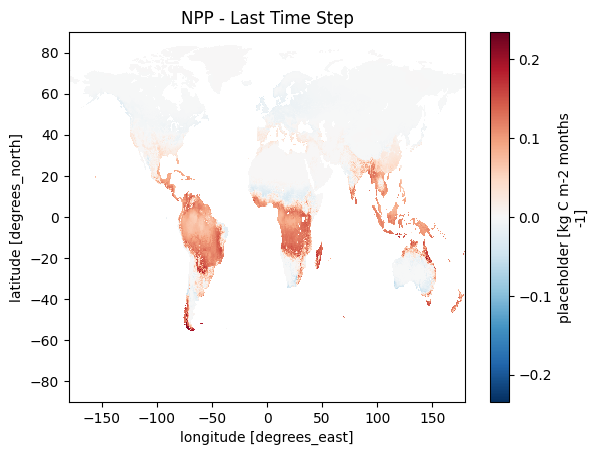

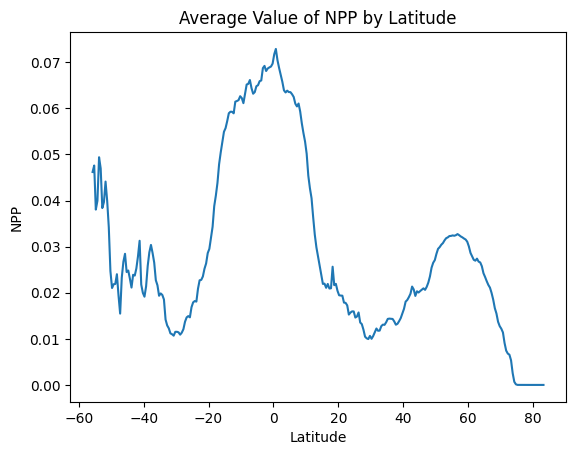

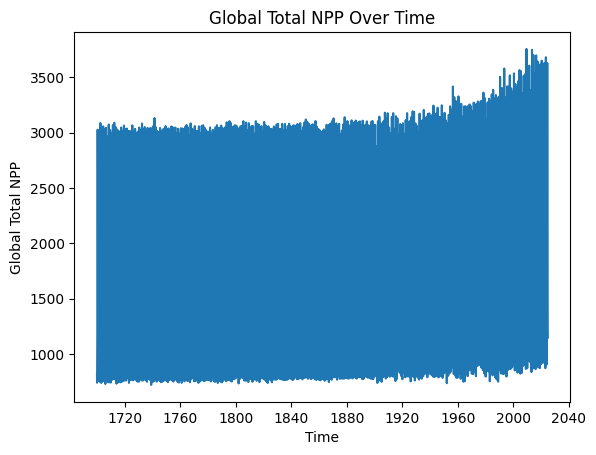

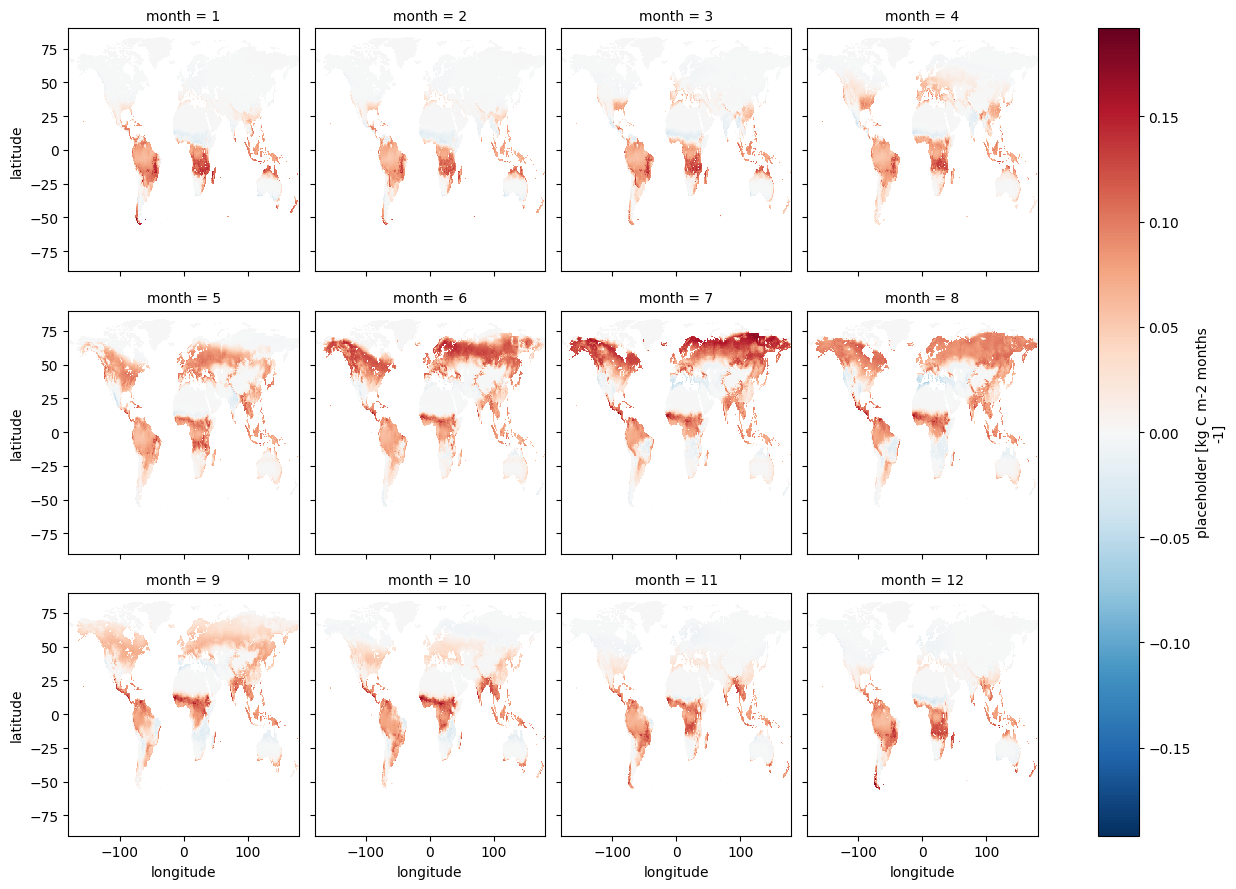

In [14]:
#Understanding the mnpp.nc dataset

#Variables, dimensions, and attributes of the dataset
mnpp = xr.open_dataset('LPJ-EOSIM_S3_spitfire_N_mnpp.nc')
print(mnpp)

mnpp = mnpp['mnpp']

print(mnpp.attrs)
print(mnpp.dims)

#Last Time Step of mnpp.nc. What does the world look like?
mnpp.isel(time=-1).plot()

plt.title("NPP - Last Time Step")
plt.show()

#Average Value by Latitude. How do values change with latitude?
lat_profile_npp = mnpp.mean(dim=["longitude", "time"])

lat_profile_npp.plot()
plt.title("Average Value of NPP by Latitude")
plt.xlabel("Latitude")
plt.ylabel("NPP")
plt.show()

#Global total NPP. How does the total NPP change over time?
global_total_npp = mnpp.sum(dim=["latitude", "longitude"])

global_total_npp.plot()
plt.title("Global Total NPP Over Time")
plt.xlabel("Time")
plt.ylabel("Global Total NPP")
plt.show()

#Weight of Grid Cells.
weights_npp = np.cos(np.deg2rad(mnpp.latitude))
weights_npp.name = "weights"
mnpp_weighted = mnpp.weighted(weights_npp)

#Weighted lat profile
lat_profile_weighted_npp = mnpp_weighted.mean(dim=["longitude", "time"])

#Weighted global mean
global_mean_weighted_npp = mnpp_weighted.mean(dim=["latitude", "longitude", "time"])

#Seasonal Cycle. How does NPP change across seasons?
seasonal_cycle_npp = mnpp.groupby("time.month").mean(dim=["time"])
seasonal_cycle_npp.plot(col="month", col_wrap=4)

<xarray.Dataset> Size: 337MB
Dimensions:    (time: 325, longitude: 720, latitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1700-12-31 1701-12-31 ... 2024-12-31
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    firec      (time, latitude, longitude) float32 337MB ...
{'units': 'kg C m-2', 'long_name': 'placeholder'}
('time', 'latitude', 'longitude')
(325, 360, 720)


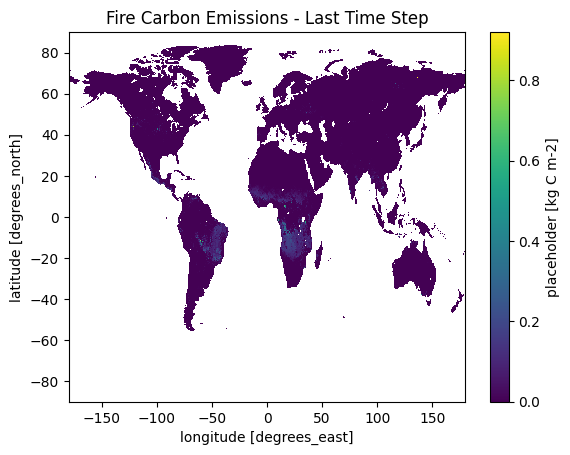

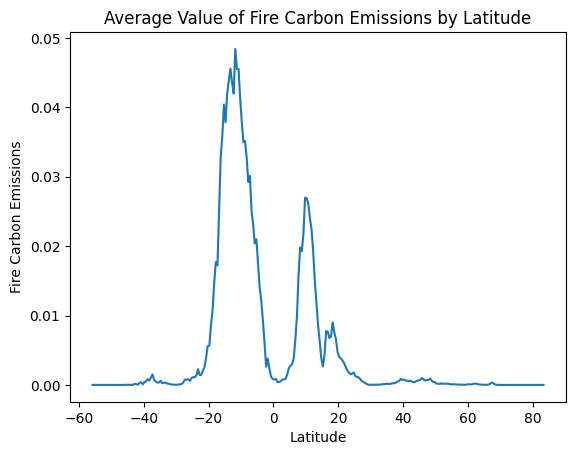

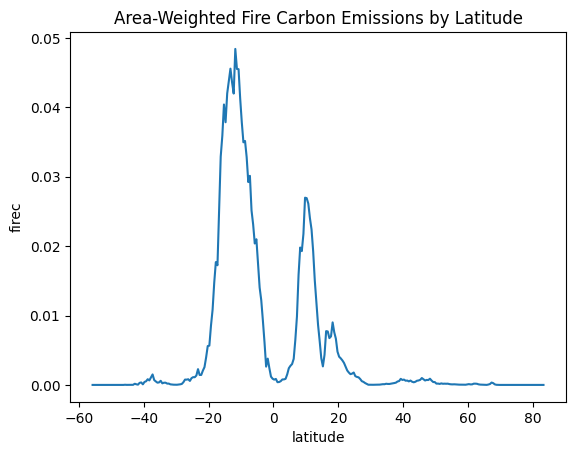

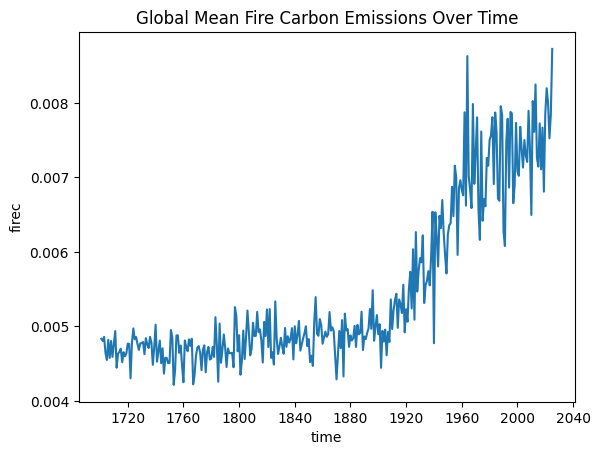

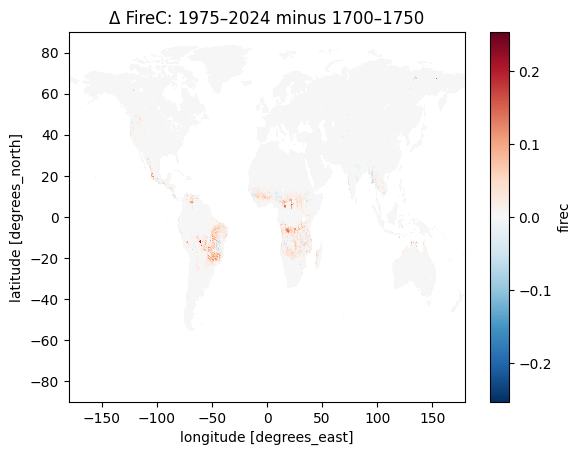

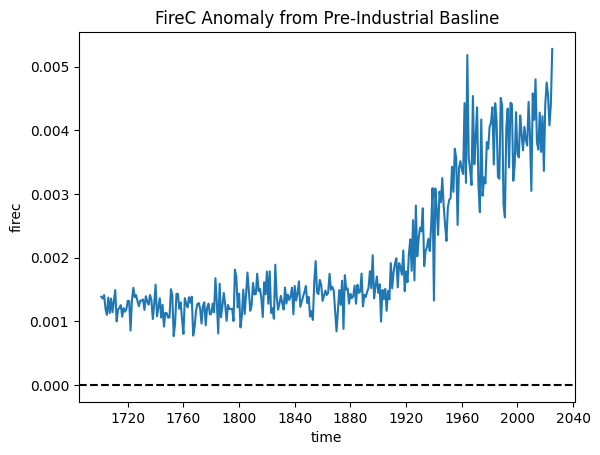

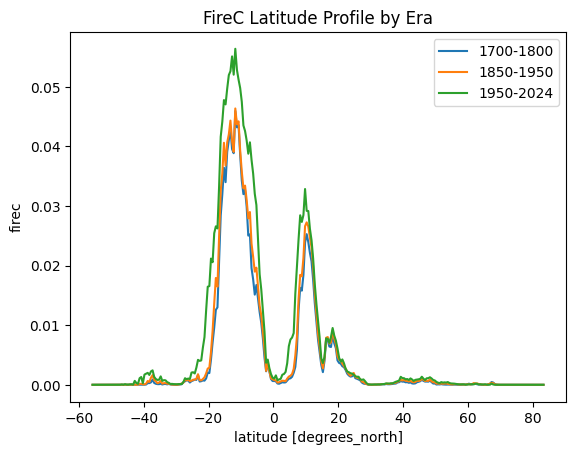

In [15]:
#Understanding the firec.nc dataset

#Variables, dimensions, and attributes of the dataset
from matplotlib.pyplot import plot


firec = xr.open_dataset('LPJ-EOSIM_S3_spitfire_N_firec.nc')
print(firec)

firec = firec['firec']

print(firec.attrs)
print(firec.dims)
print(firec.shape)

#Last Time Step of firec.nc. What does the world look like?
firec.isel(time=-1).plot()

plt.title("Fire Carbon Emissions - Last Time Step")
plt.show()

#Average Value by Latitude. How do values change with latitude?
lat_profile_firec = firec.mean(dim=["longitude", "time"])

lat_profile_firec.plot()
plt.title("Average Value of Fire Carbon Emissions by Latitude")
plt.xlabel("Latitude")
plt.ylabel("Fire Carbon Emissions")
plt.show()

#Weight of Grid Cells.
weights_firec = np.cos(np.deg2rad(firec.latitude))
weights_firec.name = "weights"
firec_weighted = firec.weighted(weights_firec)

#Weighted lat profile
lat_profile_weighted_firec = firec_weighted.mean(dim=["longitude", "time"])

lat_profile_weighted_firec.plot()
plt.title("Area-Weighted Fire Carbon Emissions by Latitude")
plt.show()

#Weighted global mean
global_mean_weighted_firec = firec_weighted.mean(dim=["latitude", "longitude"])

global_mean_weighted_firec.plot()
plt.title("Global Mean Fire Carbon Emissions Over Time")
plt.show()

#Difference map
early = firec.sel(time=slice("1700", "1750")).mean("time")
recent = firec.sel(time=slice("1975", "2024")).mean("time")
(recent - early).plot(cmap="RdBu_r", center=0)

plt.title("Δ FireC: 1975–2024 minus 1700–1750")
plt.show()

#Anomaly time series
baseline = firec.sel(time=slice("1700","1850")).mean("time")

anomaly = firec_weighted.mean(dim=["latitude", "longitude"]) - firec.sel(time=slice("1700", "1850")).mean()
anomaly.plot()
plt.axhline(0, color="k", linestyle="--")
plt.title("FireC Anomaly from Pre-Industrial Basline")
plt.show()

#Lat profile by era
for label, sl in [("1700-1800", slice("1700", "1800")),
                  ("1850-1950", slice("1850", "1950")),
                  ("1950-2024", slice("1950", "2024"))]:
    firec.sel(time=sl).mean(dim=["time", "longitude"]). plot(label=label)

plt.legend()
plt.title("FireC Latitude Profile by Era")
plt.show()

<xarray.Dataset> Size: 337MB
Dimensions:    (time: 325, longitude: 720, latitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1700-12-31 1701-12-31 ... 2024-12-31
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    soilc      (time, latitude, longitude) float32 337MB ...
{'units': 'kg C m-2', 'long_name': 'placeholder'}
('time', 'latitude', 'longitude')
(325, 360, 720)


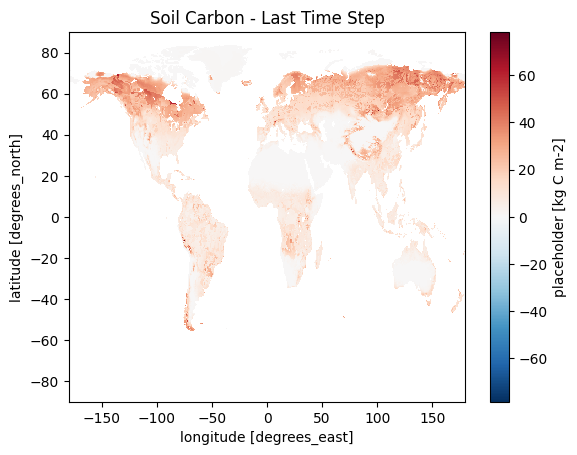

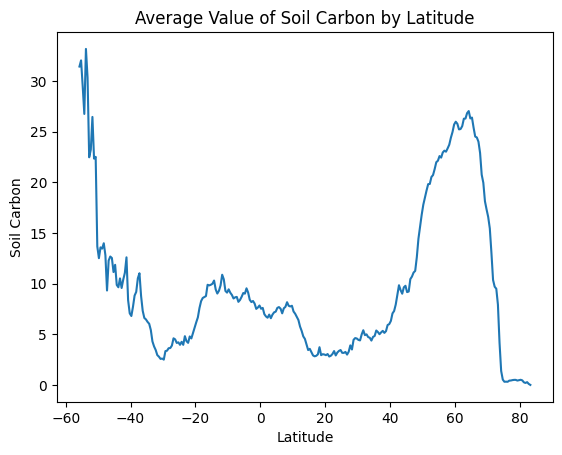

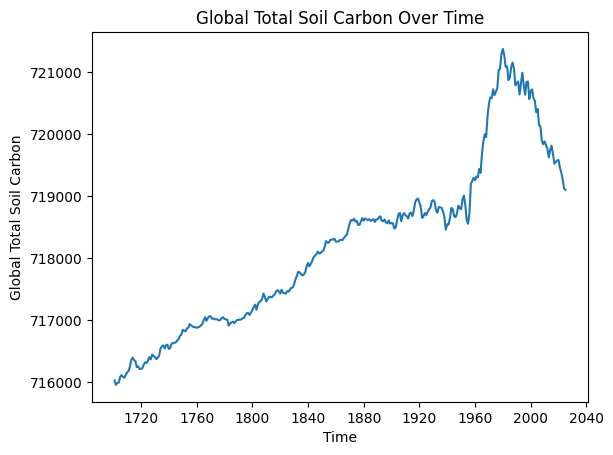

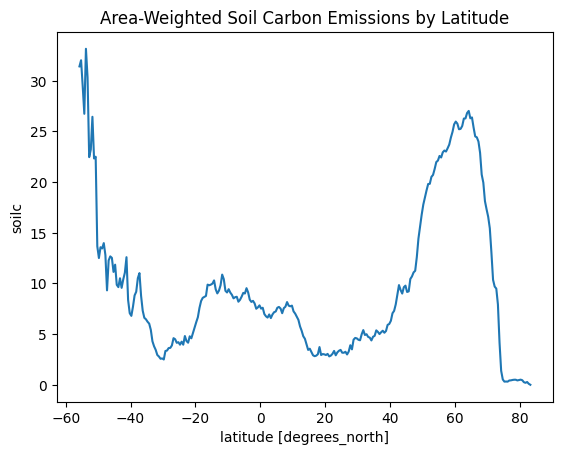

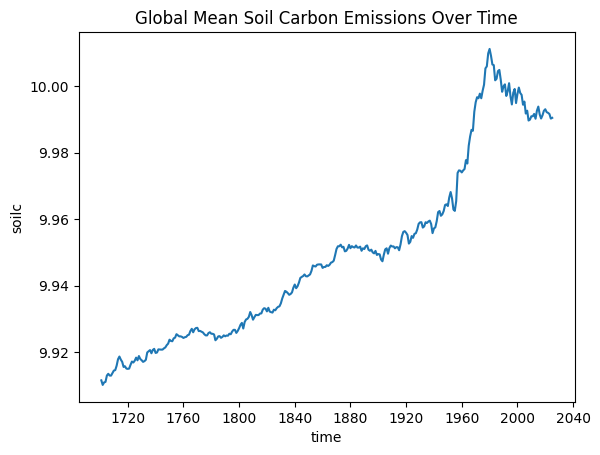

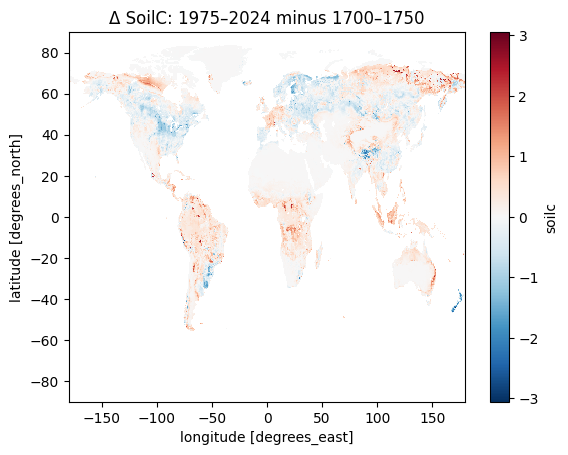

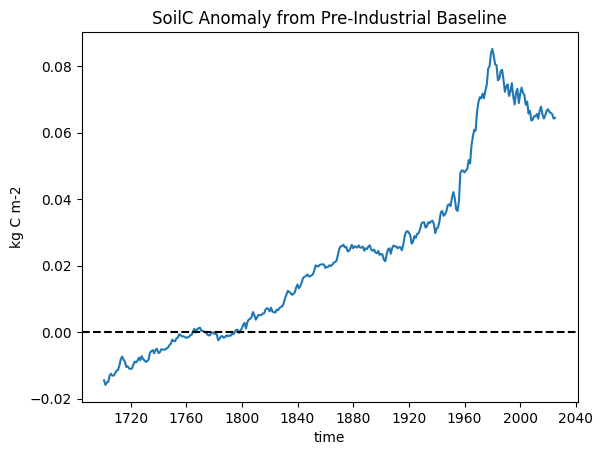

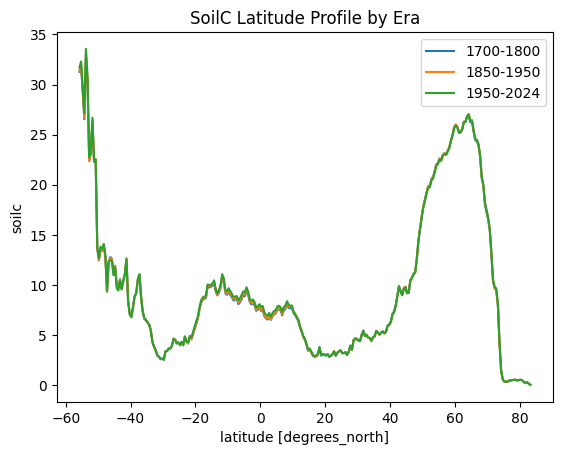

In [16]:
#Understanding the soilc.nc dataset

#Variables, dimensions, and attributes of the dataset
soilc = xr.open_dataset('LPJ-EOSIM_S3_spitfire_N_soilc.nc')
print(soilc)

soilc = soilc['soilc']

print(soilc.attrs)
print(soilc.dims)
print(soilc.shape)

#Last Time Step of soilc.nc. What does the world look like?
soilc.isel(time=-1).plot()

plt.title("Soil Carbon - Last Time Step")
plt.show()

#Average Value by Latitude. How do values change with latitude?
lat_profile_soilc = soilc.mean(dim=["longitude", "time"])

lat_profile_soilc.plot()
plt.title("Average Value of Soil Carbon by Latitude")
plt.xlabel("Latitude")
plt.ylabel("Soil Carbon")
plt.show()

#Global total Soil Carbon. How does the total Soil Carbon change over time?
global_total_soilc = soilc.sum(dim=["latitude", "longitude"])

global_total_soilc.plot()
plt.title("Global Total Soil Carbon Over Time")
plt.xlabel("Time")
plt.ylabel("Global Total Soil Carbon")
plt.show()

#Weight of Grid Cells.
weights_soilc = np.cos(np.deg2rad(soilc.latitude))
weights_soilc.name = "weights"
soilc_weighted = soilc.weighted(weights_soilc)

#Weighted lat profile
lat_profile_weighted_soilc = soilc_weighted.mean(dim=["longitude", "time"])

lat_profile_soilc.plot()
plt.title("Area-Weighted Soil Carbon Emissions by Latitude")
plt.show()

#Weighted global mean
global_mean_weighted_soilc = soilc_weighted.mean(dim=["latitude", "longitude"])

global_mean_weighted_soilc.plot()
plt.title("Global Mean Soil Carbon Emissions Over Time")
plt.show()

#Difference map
early = soilc.sel(time=slice("1700", "1750")).mean("time")
recent = soilc.sel(time=slice("1975", "2024")).mean("time")
(recent - early).plot(cmap="RdBu_r", center=0)

plt.title("Δ SoilC: 1975–2024 minus 1700–1750")
plt.show()

#Anomaly time series
baseline_soilc = global_mean_weighted_soilc.sel(time=slice("1700", "1850")).mean("time")

anomaly_soilc = global_mean_weighted_soilc - baseline_soilc

anomaly_soilc.plot()
plt.axhline(0, color="k", linestyle="--")
plt.title("SoilC Anomaly from Pre-Industrial Baseline")
plt.ylabel("kg C m-2")
plt.show()

#Lat profile by era
for label, sl in [("1700-1800", slice("1700", "1800")),
                  ("1850-1950", slice("1850", "1950")),
                  ("1950-2024", slice("1950", "2024"))]:
    soilc.sel(time=sl).mean(dim=["time", "longitude"]). plot(label=label)

plt.legend()
plt.title("SoilC Latitude Profile by Era")
plt.show()

<xarray.Dataset> Size: 337MB
Dimensions:    (time: 325, longitude: 720, latitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1700-12-31 1701-12-31 ... 2024-12-31
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    vegc       (time, latitude, longitude) float32 337MB ...
{'units': 'kg C m-2', 'long_name': 'placeholder'}
('time', 'latitude', 'longitude')
(325, 360, 720)


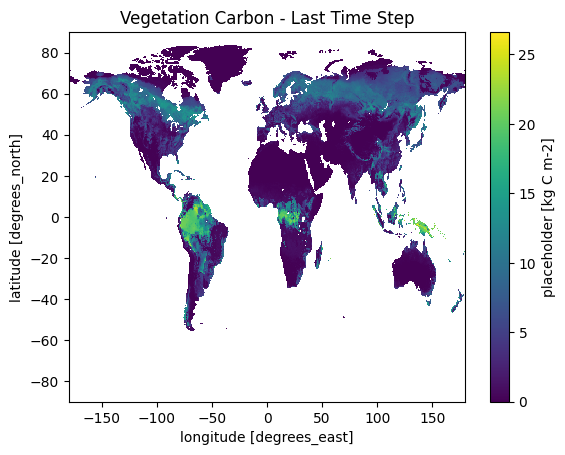

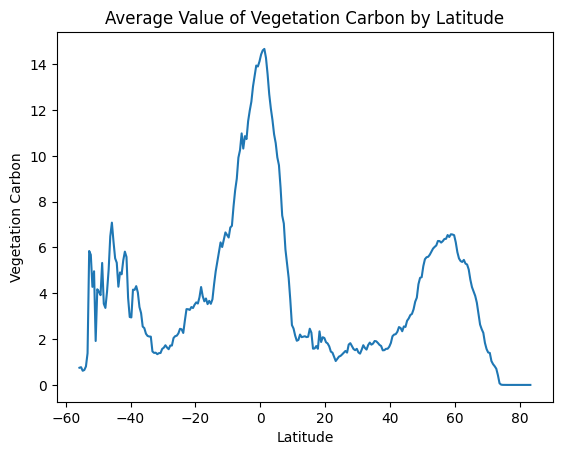

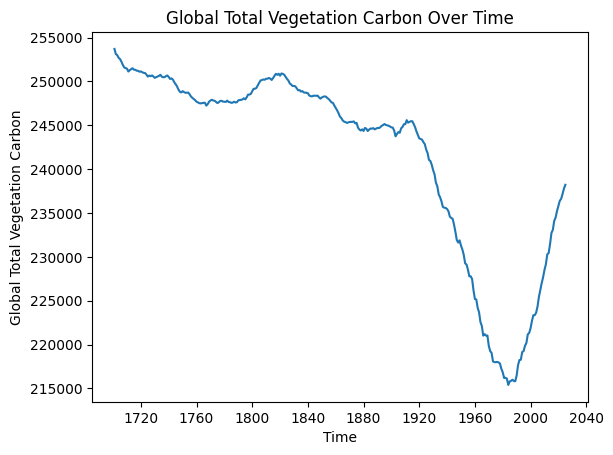

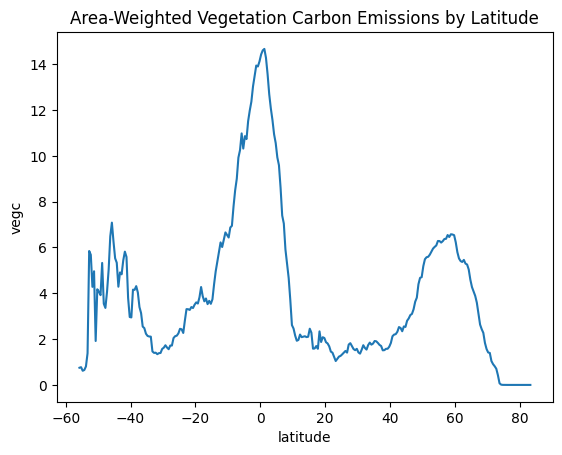

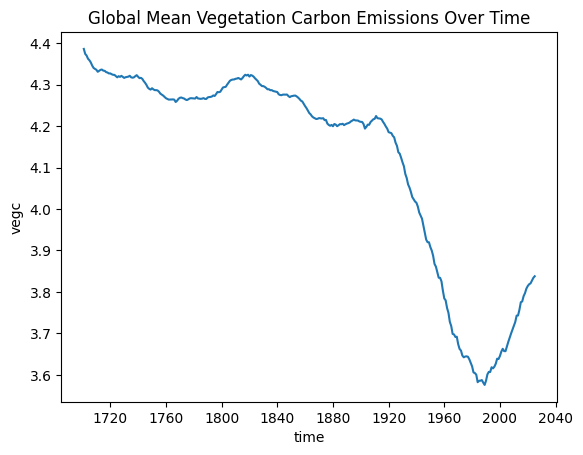

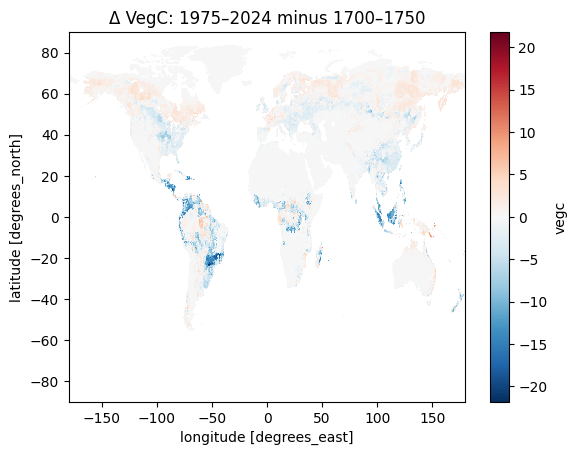

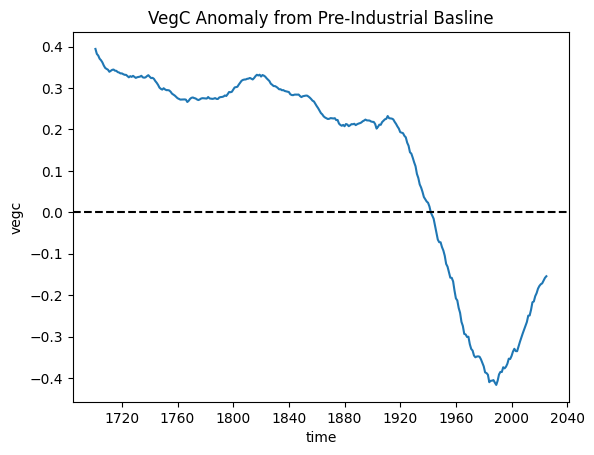

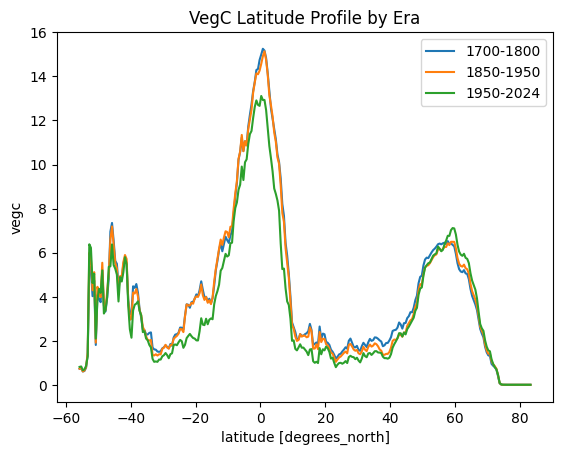

In [17]:
#Understanding the vegc.nc dataset

#Variables, dimensions, and attributes of the dataset
vegc = xr.open_dataset('LPJ-EOSIM_S3_spitfire_N_vegc.nc')
print(vegc)

vegc = vegc['vegc']

print(vegc.attrs)
print(vegc.dims)
print(vegc.shape)

#Last Time Step of vegc.nc. What does the world look like?
vegc.isel(time=-1).plot()

plt.title("Vegetation Carbon - Last Time Step")
plt.show()

#Average Value by Latitude. How do values change with latitude?
lat_profile_vegc = vegc.mean(dim=["longitude", "time"])

lat_profile_vegc.plot()
plt.title("Average Value of Vegetation Carbon by Latitude")
plt.xlabel("Latitude")
plt.ylabel("Vegetation Carbon")
plt.show()

#Global total Vegetation Carbon. How does the total Vegetation Carbon change over time?
global_total_vegc = vegc.sum(dim=["latitude", "longitude"])

global_total_vegc.plot()
plt.title("Global Total Vegetation Carbon Over Time")
plt.xlabel("Time")
plt.ylabel("Global Total Vegetation Carbon")
plt.show()

#Weight of Grid Cells.
weights_vegc = np.cos(np.deg2rad(vegc.latitude))
weights_vegc.name = "weights"
vegc_weighted = vegc.weighted(weights_vegc)

#Weighted lat profile
lat_profile_weighted_vegc = vegc_weighted.mean(dim=["longitude", "time"])

lat_profile_weighted_vegc.plot()
plt.title("Area-Weighted Vegetation Carbon Emissions by Latitude")
plt.show()

#Weighted global mean
global_mean_weighted_vegc = vegc_weighted.mean(dim=["latitude", "longitude"])

global_mean_weighted_vegc.plot()
plt.title("Global Mean Vegetation Carbon Emissions Over Time")
plt.show()

#Difference map
early = vegc.sel(time=slice("1700", "1750")).mean("time")
recent = vegc.sel(time=slice("1975", "2024")).mean("time")
(recent - early).plot(cmap="RdBu_r", center=0)

plt.title("Δ VegC: 1975–2024 minus 1700–1750")
plt.show()

#Anomaly time series
baseline = vegc.sel(time=slice("1700","1850")).mean("time")

anomaly = vegc_weighted.mean(dim=["latitude", "longitude"]) - vegc.sel(time=slice("1700", "1850")).mean()
anomaly.plot()
plt.axhline(0, color="k", linestyle="--")
plt.title("VegC Anomaly from Pre-Industrial Basline")
plt.show()

#Lat profile by era
for label, sl in [("1700-1800", slice("1700", "1800")),
                  ("1850-1950", slice("1850", "1950")),
                  ("1950-2024", slice("1950", "2024"))]:
    vegc.sel(time=sl).mean(dim=["time", "longitude"]). plot(label=label)

plt.legend()
plt.title("VegC Latitude Profile by Era")
plt.show()

Cross-Variable ideas. 

Question 1: Is high-latitude soil carbon driving the gobal decline? 

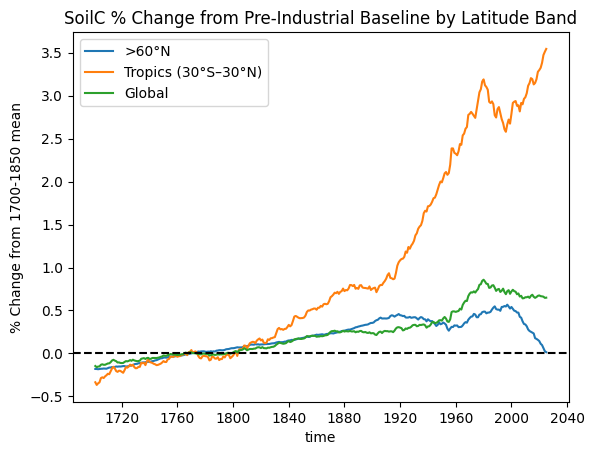

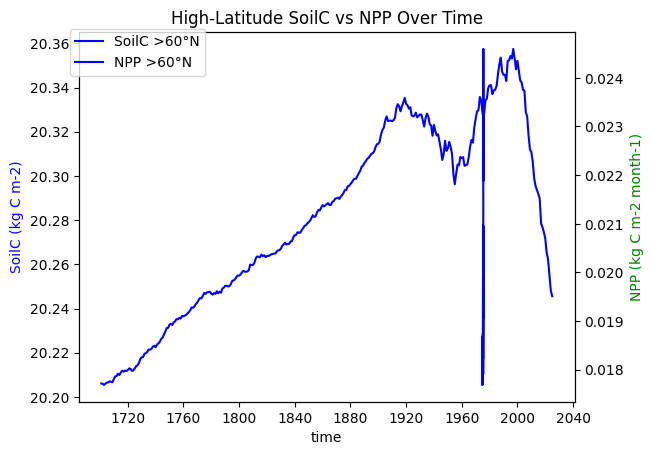

In [21]:
#Define a reusable weighted mean function
def weighted_ts(da):
    w = np.cos(np.deg2rad(da.latitude))
    w.name = "weights"
    return da.weighted(w).mean(dim=["latitude", "longitude"])

#Split soilc into latitude bands
soilc_highlat = weighted_ts(soilc.sel(latitude=slice(60, 90)))
soilc_tropics = weighted_ts(soilc.sel(latitude=slice(-30, 30)))
soilc_global = weighted_ts(soilc)

#Normalize to % change from pre-industrial baseline
fig, ax = plt.subplots()
for ts, label in [(soilc_highlat, ">60°N"),
                  (soilc_tropics, "Tropics (30°S–30°N)"),
                  (soilc_global, "Global")]:
    baseline = ts.sel(time=slice("1700", "1850")).mean()
    pct_change = (ts - baseline) / baseline * 100
    pct_change.plot(ax=ax, label=label)

plt.axhline(0, color="k", linestyle="--")
plt.legend()
plt.title("SoilC % Change from Pre-Industrial Baseline by Latitude Band")
plt.ylabel("% Change from 1700-1850 mean")
plt.show()

#Compare NPP at high latitudes as a proxy for warming-driven productivity
# (if NPP rises but soilc falls at >60N, decomposition is outpacing inputs)
mnpp_highlat = weighted_ts(mnpp.sel(latitude=slice(60, 90)))
mnpp_annual_highlat = mnpp_highlat.groupby("time.year").mean()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
soilc_highlat.plot(ax=ax1, color="blue", label="SoilC >60°N")
mnpp_annual_highlat.plot(ax=ax2, color="blue", label="NPP >60°N")
ax1.set_ylabel("SoilC (kg C m-2)", color="blue")
ax2.set_ylabel("NPP (kg C m-2 month-1)", color="green")
plt.title("High-Latitude SoilC vs NPP Over Time")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


Question 2: El Niño flux response

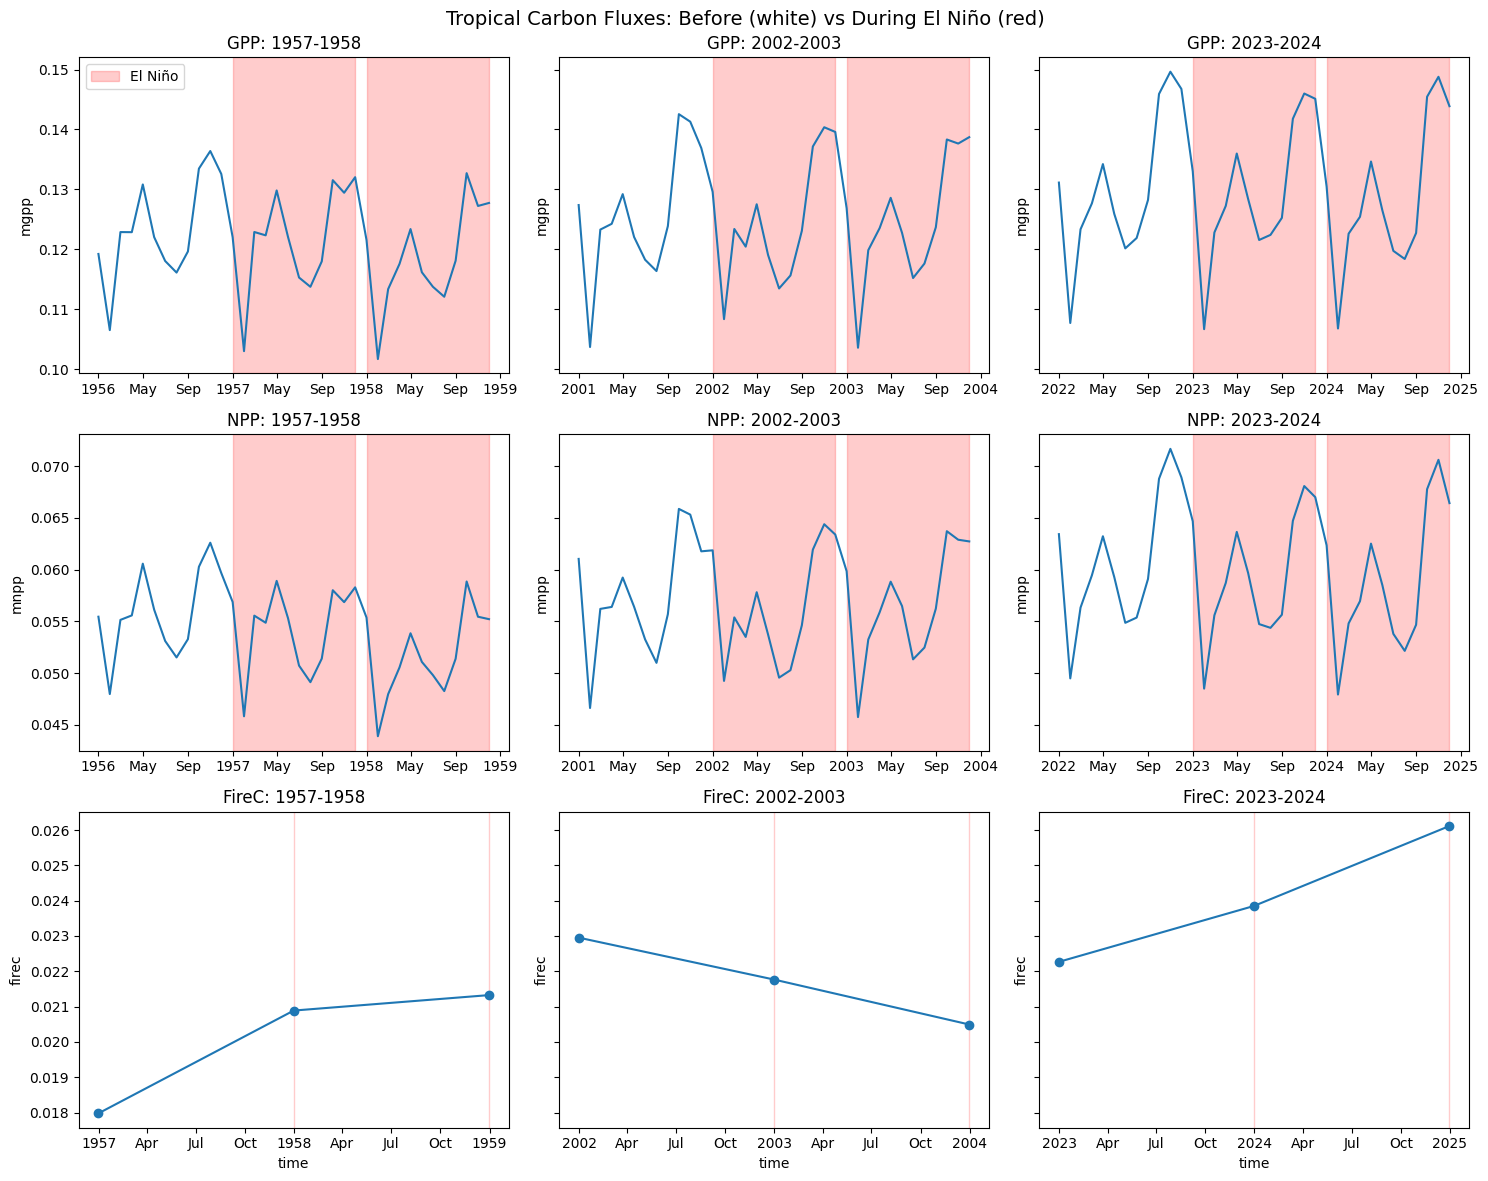

In [34]:
#    Each entry: event name → (el nino years, normal year before)
events = {
    "1957-1958": ([1957, 1958], 1956),
    "2002-2003": ([2002, 2003], 2001),
    "2023-2024": ([2023, 2024], 2022),
}

#Focus on tropics where El Niño signal is strongest
mgpp_trop = weighted_ts(mgpp.sel(latitude=slice(-20, 20)))
mnpp_trop = weighted_ts(mnpp.sel(latitude=slice(-20, 20)))
firec_trop = weighted_ts(firec.sel(latitude=slice(-20, 20)))

# Plot 3x3 grid (rows = GPP, NPP, FireC | columns = events)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey="row")

for col, (event_name, (en_years, normal_year)) in enumerate(events.items()):
    all_years = [normal_year] + en_years

    # GPP
    mgpp_case = mgpp_trop.sel(time=mgpp_trop.time.dt.year.isin(all_years))
    mgpp_case.plot(ax=axes[0][col])
    for yr in en_years:
        axes[0][col].axvspan(
            mgpp_case.time.sel(time=str(yr)).min().values,
            mgpp_case.time.sel(time=str(yr)).max().values,
            alpha=0.2, color="red", label="El Niño" if yr == en_years[0] else "")
    axes[0][col].set_title(f"GPP: {event_name}")
    axes[0][col].set_xlabel("")

    # NPP
    mnpp_case = mnpp_trop.sel(time=mnpp_trop.time.dt.year.isin(all_years))
    mnpp_case.plot(ax=axes[1][col])
    for yr in en_years:
        axes[1][col].axvspan(
            mnpp_case.time.sel(time=str(yr)).min().values,
            mnpp_case.time.sel(time=str(yr)).max().values,
            alpha=0.2, color="red")
    axes[1][col].set_title(f"NPP: {event_name}")
    axes[1][col].set_xlabel("")

    # FireC
    firec_case = firec_trop.sel(time=firec_trop.time.dt.year.isin(all_years))
    firec_case.plot(ax=axes[2][col], marker="o")
    for yr in en_years:
        axes[2][col].axvspan(
            firec_case.time.sel(time=str(yr)).min().values,
            firec_case.time.sel(time=str(yr)).max().values,
            alpha=0.2, color="red")
    axes[2][col].set_title(f"FireC: {event_name}")

axes[0][0].legend()
plt.suptitle("Tropical Carbon Fluxes: Before (white) vs During El Niño (red)", fontsize=14)
plt.tight_layout()
plt.show()

I remeber the year 2023 being a year full of fires world wide. On top of that, the El Niño was developing which would last into 2024. Did the El Niño-driven drought stress amplify fire activity gloablly, and do we see the effects in our firec data?

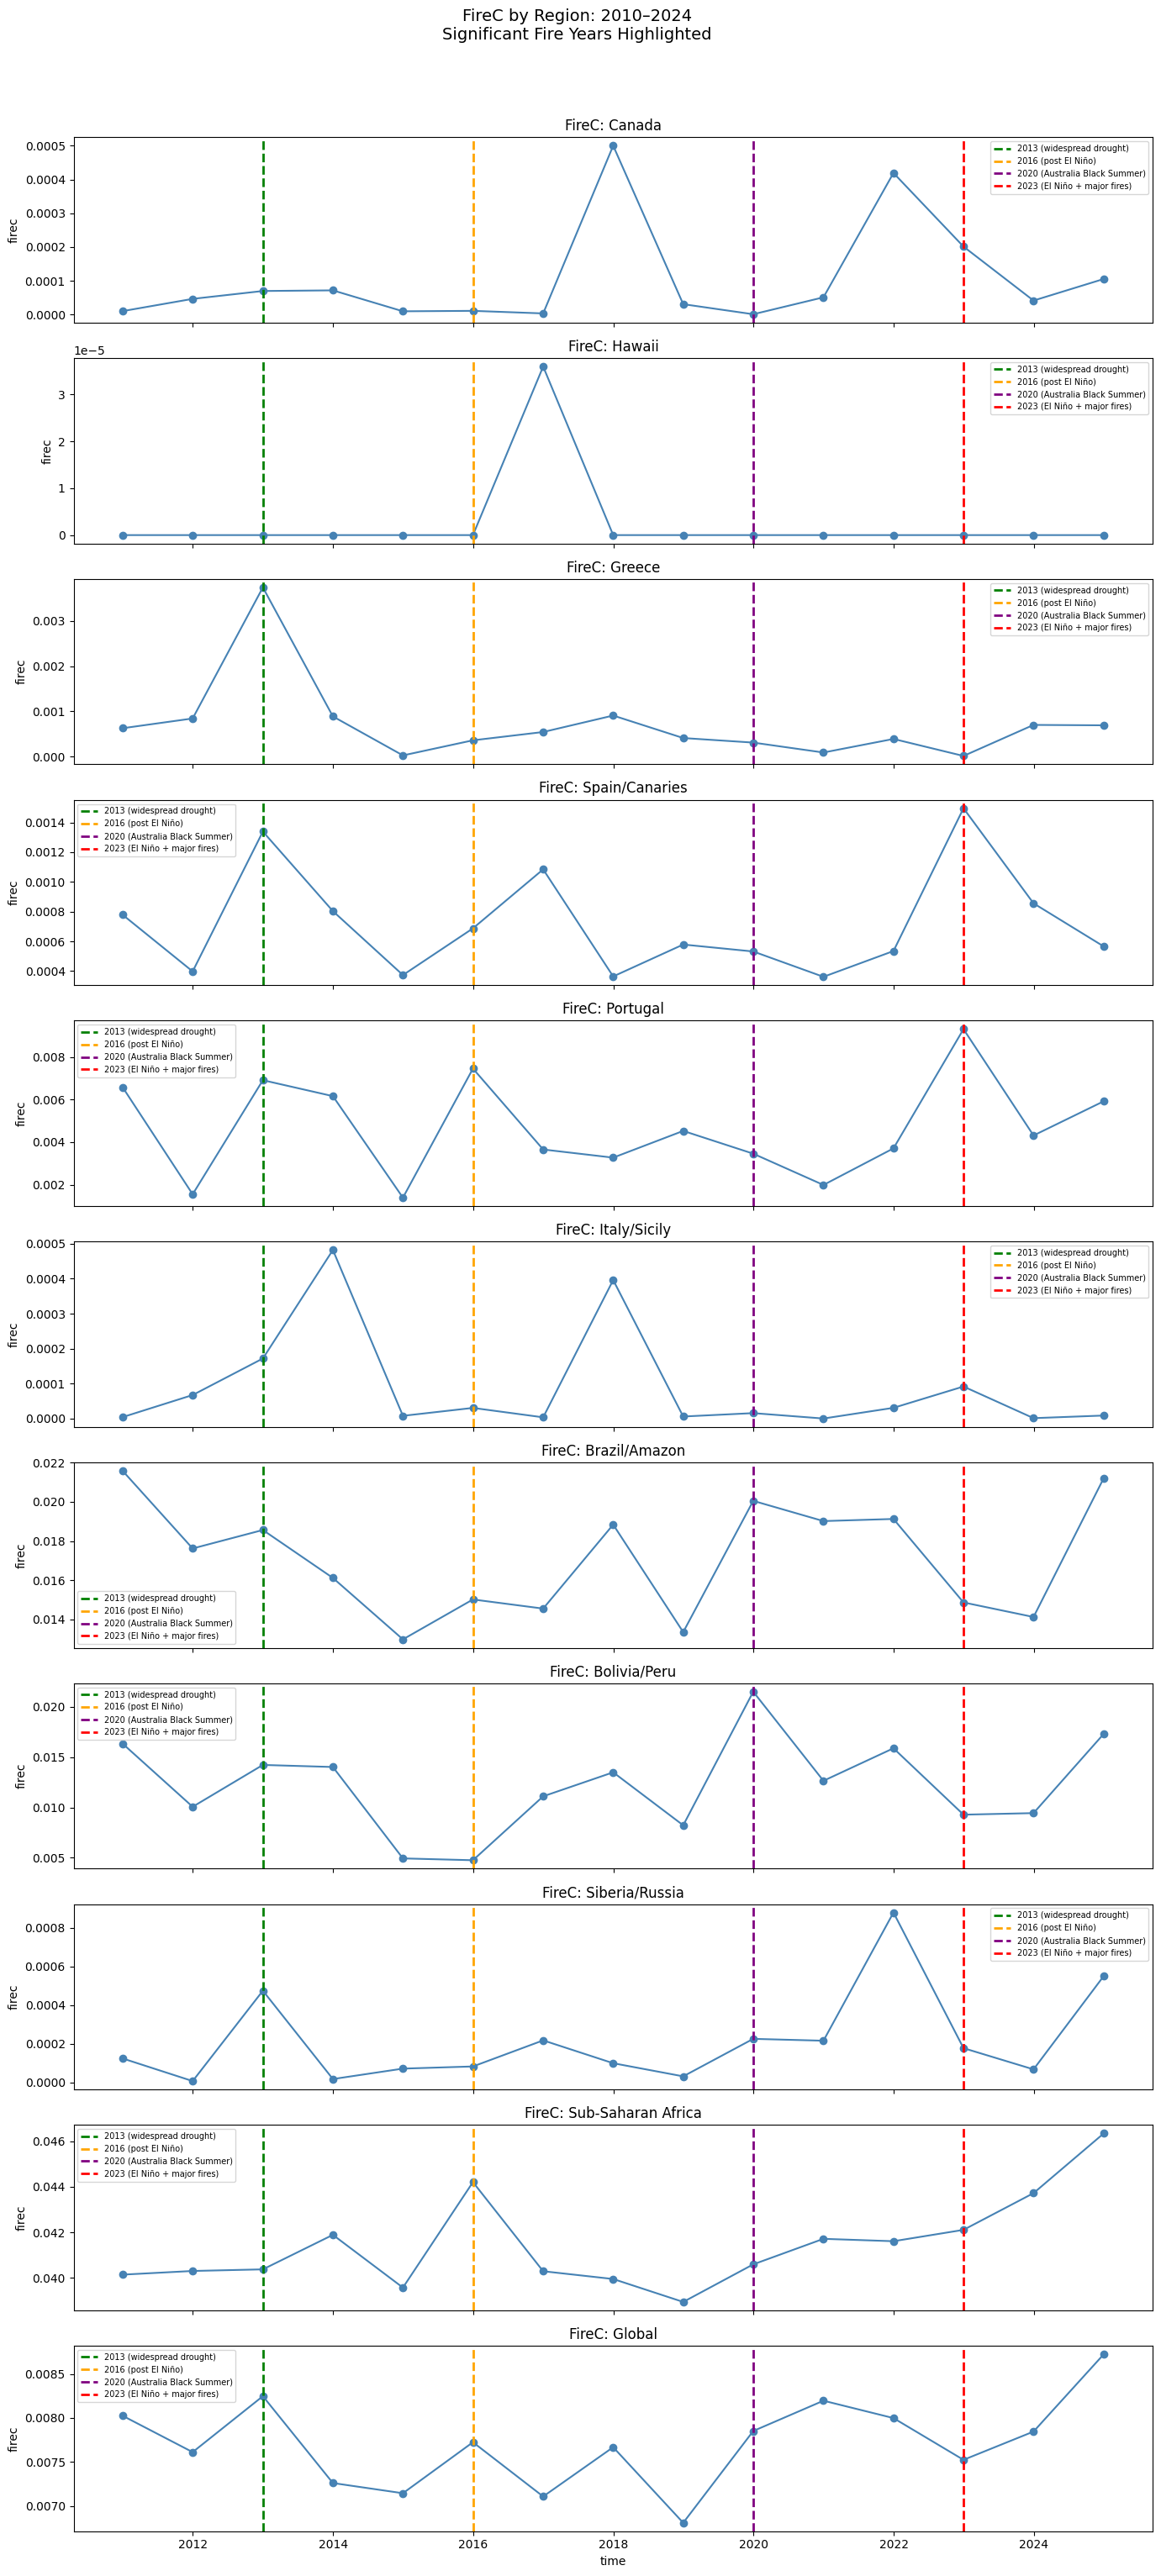

In [43]:
import pandas as pd

# Define regions
regions = {
    "Canada":             {"lat": slice(50, 70),  "lon": slice(-140, -60)},
    "Hawaii":             {"lat": slice(18, 23),  "lon": slice(-161, -154)},
    "Greece":             {"lat": slice(35, 42),  "lon": slice(20, 27)},
    "Spain/Canaries":     {"lat": slice(27, 44),  "lon": slice(-18, 4)},
    "Portugal":           {"lat": slice(36, 42),  "lon": slice(-9, -6)},
    "Italy/Sicily":       {"lat": slice(36, 48),  "lon": slice(12, 18)},
    "Brazil/Amazon":      {"lat": slice(-20, 5),  "lon": slice(-75, -45)},
    "Bolivia/Peru":       {"lat": slice(-20, -5), "lon": slice(-75, -55)},
    "Siberia/Russia":     {"lat": slice(50, 75),  "lon": slice(60, 140)},
    "Sub-Saharan Africa": {"lat": slice(-20, 15), "lon": slice(10, 45)},
    "Global":             {"lat": slice(-90, 90), "lon": slice(-180, 180)},
}

# Significant fire years to mark
fire_years = {
    "2013-01-01": ("green",  "2013 (widespread drought)"),
    "2016-01-01": ("orange", "2016 (post El Niño)"),
    "2020-01-01": ("purple", "2020 (Australia Black Summer)"),
    "2023-01-01": ("red",    "2023 (El Niño + major fires)"),
}

for year, (color, label) in fire_years.items():
    ax.axvline(pd.Timestamp(year),
               color=color, linewidth=2, linestyle="--", label=label)

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 30), sharex=True)

for ax, (region_name, coords) in zip(axes, regions.items()):
    firec_region = firec.sel(latitude=coords["lat"],
                             longitude=coords["lon"])
    firec_ts = weighted_ts(firec_region)

    # Extended window 2010-2024
    firec_zoom = firec_ts.sel(time=firec_ts.time.dt.year >= 2010)
    firec_zoom.plot(ax=ax, marker="o", color="steelblue")

    # Mark each significant fire year
    for year, (color, label) in fire_years.items():
        ax.axvline(pd.Timestamp(f"{year}"),
                   color=color, linewidth=2, linestyle="--", label=label)

    ax.set_title(f"FireC: {region_name}")
    ax.legend(fontsize=7)
    ax.set_xlabel("")

axes[-1].set_xlabel("time")
plt.suptitle("FireC by Region: 2010–2024\nSignificant Fire Years Highlighted",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

SoilC signal after large fires

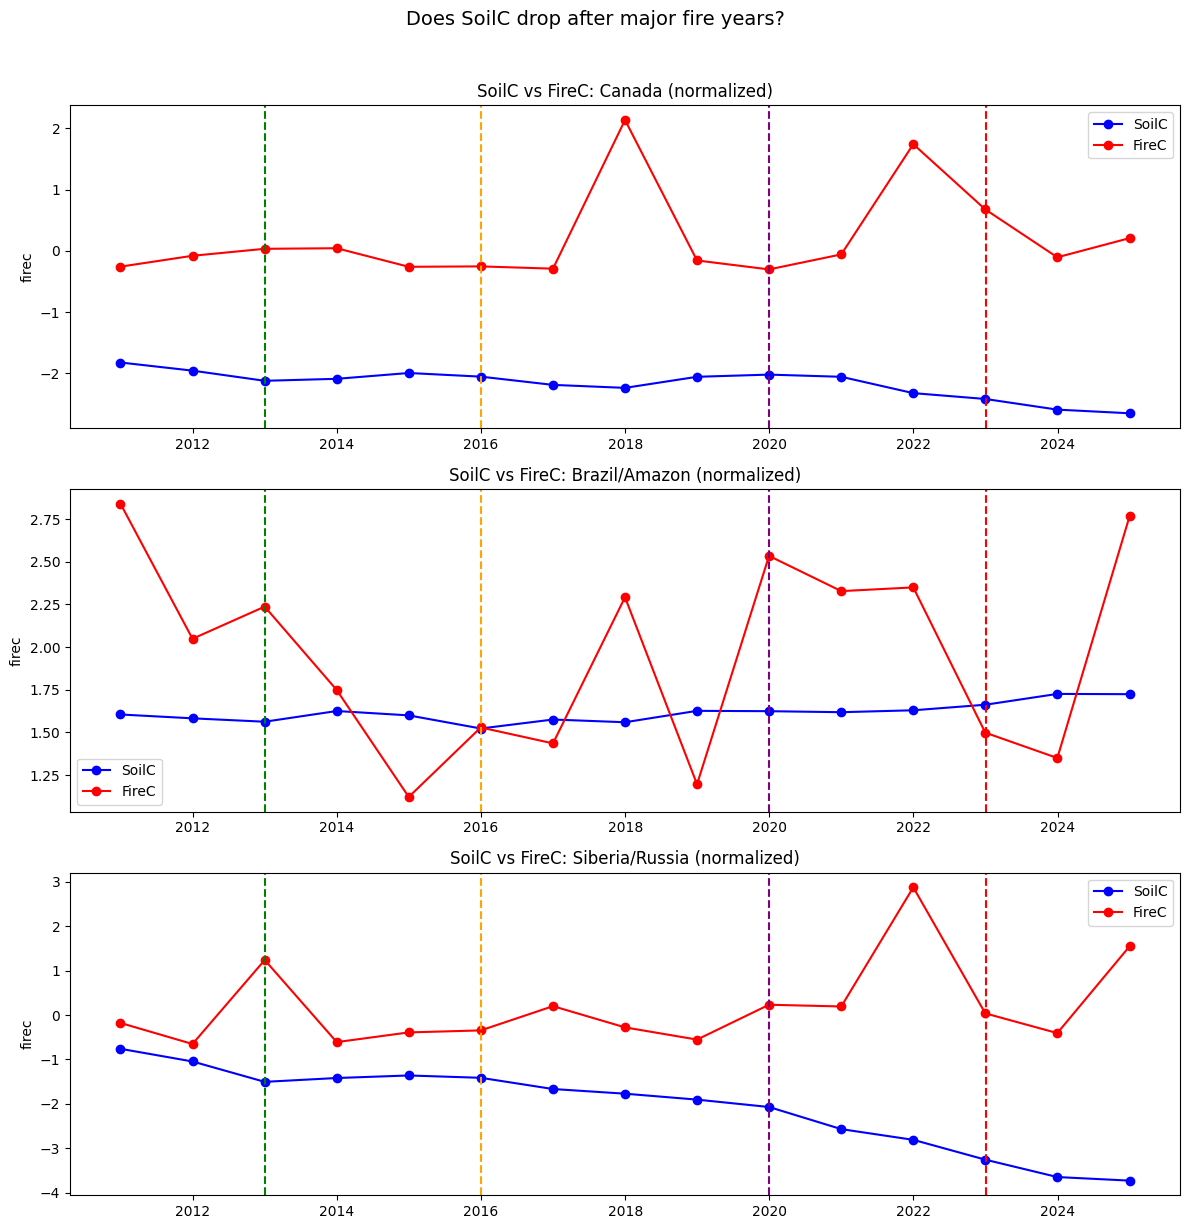

In [44]:
# Compare soilc at fire hotspot regions before and after major fire years
fire_regions = {
    "Canada":        {"lat": slice(50, 70), "lon": slice(-140, -60)},
    "Brazil/Amazon": {"lat": slice(-20, 5), "lon": slice(-75, -45)},
    "Siberia/Russia":{"lat": slice(50, 75), "lon": slice(60, 140)},
}

fig, axes = plt.subplots(len(fire_regions), 1, figsize=(12, 12), sharex=False)

for ax, (region_name, coords) in zip(axes, fire_regions.items()):
    soilc_region = weighted_ts(soilc.sel(latitude=coords["lat"],
                                         longitude=coords["lon"]))
    firec_region = weighted_ts(firec.sel(latitude=coords["lat"],
                                         longitude=coords["lon"]))

    # Normalize both to same scale for comparison
    soilc_norm = (soilc_region - soilc_region.mean()) / soilc_region.std()
    firec_norm = (firec_region - firec_region.mean()) / firec_region.std()

    # Zoom to 2010-2024
    soilc_zoom = soilc_norm.sel(time=soilc_norm.time.dt.year >= 2010)
    firec_zoom = firec_norm.sel(time=firec_norm.time.dt.year >= 2010)

    soilc_zoom.plot(ax=ax, color="blue", marker="o", label="SoilC")
    firec_zoom.plot(ax=ax, color="red", marker="o", label="FireC")

    # Mark major fire years
    for year, color in [("2013-01-01", "green"), 
                        ("2016-01-01", "orange"),
                        ("2020-01-01", "purple"), 
                        ("2023-01-01", "red")]:
        ax.axvline(pd.Timestamp(year), color=color, 
                   linewidth=1.5, linestyle="--")

    ax.set_title(f"SoilC vs FireC: {region_name} (normalized)")
    ax.legend()
    ax.set_xlabel("")

plt.suptitle("Does SoilC drop after major fire years?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Correlation matrix heatmap

In [45]:
import pandas as pd
import seaborn as sns

# Build global mean time series for all variables
gm_firec = weighted_ts(firec)
gm_soilc = weighted_ts(soilc)
gm_vegc  = weighted_ts(vegc)
gm_mgpp  = weighted_ts(mgpp).groupby("time.year").mean()
gm_mnpp  = weighted_ts(mnpp).groupby("time.year").mean()

# Align all to annual (firec, soilc, vegc are already annual)
df = pd.DataFrame({
    "FireC": gm_firec.values,
    "SoilC": gm_soilc.values,
    "VegC":  gm_vegc.values,
    "GPP":   gm_mgpp.values,
    "NPP":   gm_mnpp.values,
}, index=firec.time.values)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="RdBu_r", 
            center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Cross-Variable Correlation Matrix")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'